<a href="https://colab.research.google.com/github/kpraneeth-526/AI_Folder/blob/main/anime_item_based_collab_filtering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
anime = pd.read_csv('anime.csv')
ratings = pd.read_csv('rating.csv')

ratings = ratings[ratings['rating'] != -1]

anime = anime[['anime_id', 'name']]
ratings = ratings[['user_id', 'anime_id', 'rating']]
import html
anime['name'] = anime['name'].apply(html.unescape)

anime.head()

,anime_id,name
0,32281,Kimi no Na wa.
1,5114,Fullmetal Alchemist: Brotherhood
2,28977,Gintama°
3,9253,Steins;Gate
4,9969,Gintama'


In [ ]:
ratings.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


In [ ]:
df = ratings.merge(anime, on='anime_id')
df.head()

,user_id,anime_id,rating,name
0,1,8074,10,Highschool of the Dead
1,3,8074,6,Highschool of the Dead
2,5,8074,2,Highschool of the Dead
3,12,8074,6,Highschool of the Dead
4,14,8074,6,Highschool of the Dead


In [ ]:
df.shape

(6337239, 4)

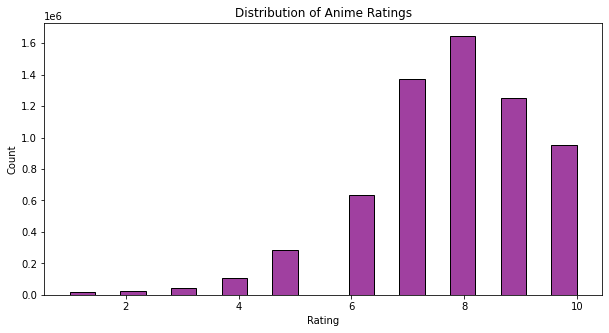

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['rating'], bins=20, color="purple")
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


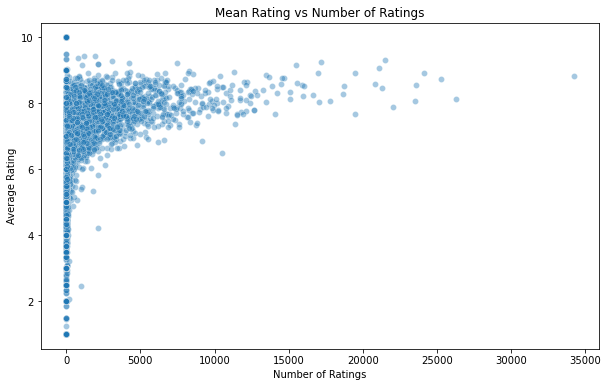

In [ ]:
rating_stats = df.groupby('name')['rating'].agg(['mean', 'count'])

plt.figure(figsize=(10,6))
sns.scatterplot(data=rating_stats, x='count', y='mean', alpha=0.4)
plt.title("Mean Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()


In [ ]:
df.groupby('name').describe()


user_id                \
                                                     count          mean   
name                                                                       
"0"                                                   17.0  39541.529412   
"Aesop" no Ohanashi yori: Ushi to Kaeru, Yokuba...     1.0  43710.000000   
"Bungaku Shoujo" Kyou no Oyatsu: Hatsukoi            635.0  36056.689764   
"Bungaku Shoujo" Memoire                             662.0  36482.870091   
"Bungaku Shoujo" Movie                              1295.0  37236.756757   
...                                                    ...           ...   
xxxHOLiC Kei                                        2796.0  37520.557225   
xxxHOLiC Movie: Manatsu no Yoru no Yume             1889.0  38516.417681   
xxxHOLiC Rou                                        1190.0  36301.163866   
xxxHOLiC Shunmuki                                   1534.0  37849.250326   
◯                                                      6.0  30347.000000   

                                                                           \
                                                             std      min   
name                                                                        
"0"                                                 17640.530236  12423.0   
"Aesop" no Ohanashi yori: Ushi to Kaeru, Yokuba...           NaN  43710.0   
"Bungaku Shoujo" Kyou no Oyatsu: Hatsukoi           21461.164113    160.0   
"Bungaku Shoujo" Memoire                            20350.888112    160.0   
"Bungaku Shoujo" Movie                              20929.113905     14.0   
...                                                          ...      ...   
xxxHOLiC Kei                                        21225.224056     43.0   
xxxHOLiC Movie: Manatsu no Yoru no Yume             21199.847887    269.0   
xxxHOLiC Rou                                        20087.241785    160.0   
xxxHOLiC Shunmuki                                   20997.452224     43.0   
◯                                                   20009.898580   3009.0   

                                                                       \
                                                         25%      50%   
name                                                                    
"0"                                                 25701.00  41571.0   
"Aesop" no Ohanashi yori: Ushi to Kaeru, Yokuba...  43710.00  43710.0   
"Bungaku Shoujo" Kyou no Oyatsu: Hatsukoi           17058.50  34333.0   
"Bungaku Shoujo" Memoire                            21591.25  34198.0   
"Bungaku Shoujo" Movie                              21089.00  35682.0   
...                                                      ...      ...   
xxxHOLiC Kei                                        19462.00  40286.0   
xxxHOLiC Movie: Manatsu no Yoru no Yume             19869.00  45885.0   
xxxHOLiC Rou                                        21568.00  34294.5   
xxxHOLiC Shunmuki                                   20533.25  40497.0   
◯                                                   15837.25  32831.5   

                                                                       \
                                                         75%      max   
name                                                                    
"0"                                                 53492.00  70990.0   
"Aesop" no Ohanashi yori: Ushi to Kaeru, Yokuba...  43710.00  43710.0   
"Bungaku Shoujo" Kyou no Oyatsu: Hatsukoi           54654.00  73502.0   
"Bungaku Shoujo" Memoire                            54237.50  73510.0   
"Bungaku Shoujo" Movie                              55225.00  73502.0   
...                                                      ...      ...   
xxxHOLiC Kei                                        55357.00  73507.0   
xxxHOLiC Movie: Manatsu no Yoru no Yume             57482.00  73507.0   
xxxHOLiC Rou                                        53496.25  73503.0   
xxxHOLiC

In [ ]:
df.groupby('name')['rating'].mean().head()


,rating
name,
"""0""",4.866667
"""Aesop"" no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",1.000000
"""Bungaku Shoujo"" Kyou no Oyatsu: Hatsukoi",7.346154
"""Bungaku Shoujo"" Memoire",7.733716
"""Bungaku Shoujo"" Movie",7.832827


In [ ]:
rating_counts = df['name'].value_counts()
popular_anime = rating_counts[rating_counts >= 400].index

df_small = df[df['name'].isin(popular_anime)]

user_anime_matrix = df_small.pivot_table(
    index='user_id',
    columns='name',
    values='rating'
)




In [ ]:
user_anime_matrix.head()


name,"""Bungaku Shoujo"" Kyou no Oyatsu: Hatsukoi","""Bungaku Shoujo"" Memoire","""Bungaku Shoujo"" Movie",.hack//G.U. Returner,.hack//G.U. Trilogy,.hack//Gift,.hack//Intermezzo,.hack//Liminality,.hack//Quantum,.hack//Roots,...,ef: A Tale of Melodies.,ef: A Tale of Melodies. - Prologue,ef: A Tale of Memories.,ef: A Tale of Memories. - Prologue,s.CRY.ed,xxxHOLiC,xxxHOLiC Kei,xxxHOLiC Movie: Manatsu no Yoru no Yume,xxxHOLiC Rou,xxxHOLiC Shunmuki
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
anime_corr = user_anime_matrix.corr(method='pearson', min_periods=50)

anime_corr

name,"""Bungaku Shoujo"" Kyou no Oyatsu: Hatsukoi","""Bungaku Shoujo"" Memoire","""Bungaku Shoujo"" Movie",.hack//G.U. Returner,.hack//G.U. Trilogy,.hack//Gift,.hack//Intermezzo,.hack//Liminality,.hack//Quantum,.hack//Roots,...,ef: A Tale of Melodies.,ef: A Tale of Melodies. - Prologue,ef: A Tale of Memories.,ef: A Tale of Memories. - Prologue,s.CRY.ed,xxxHOLiC,xxxHOLiC Kei,xxxHOLiC Movie: Manatsu no Yoru no Yume,xxxHOLiC Rou,xxxHOLiC Shunmuki
name,,,,,,,,,,,,,,,,,,,,,
"""Bungaku Shoujo"" Kyou no Oyatsu: Hatsukoi",1.000000,0.744635,0.637777,NaN,0.454444,0.594027,0.603640,0.472422,0.441831,0.427704,...,0.325641,0.351627,0.334864,0.348514,0.138261,0.374278,0.492078,0.457717,0.447106,0.435606
"""Bungaku Shoujo"" Memoire",0.744635,1.000000,0.765973,0.556470,0.388148,0.445039,0.474940,0.536322,0.431886,0.288330,...,0.402413,0.330238,0.351132,0.265461,0.098599,0.331379,0.391796,0.379595,0.407135,0.394739
"""Bungaku Shoujo"" Movie",0.637777,0.765973,1.000000,0.466480,0.368030,0.374839,0.452996,0.473985,0.404275,0.341974,...,0.365946,0.326952,0.388724,0.230482,0.173804,0.232156,0.335691,0.324071,0.361359,0.301690
.hack//G.U. Returner,NaN,0.556470,0.466480,1.000000,0.698365,0.617314,0.673917,0.598627,0.533943,0.665746,...,0.427881,NaN,0.354862,0.262569,0.417124,0.246732,0.327878,0.379263,0.343318,0.301565
.hack//G.U. Trilogy,0.454444,0.388148,0.368030,0.698365,1.000000,0.552365,0.554392,0.512949,0.471152,0.596812,...,0.339618,NaN,0.402542,0.346342,0.395361,0.237799,0.322899,0.328929,0.324105,0.226928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xxxHOLiC,0.374278,0.331379,0.232156,0.246732,0.237799,0.216272,0.162925,0.270263,0.235611,0.212103,...,0.315615,0.395786,0.318541,0.461533,0.213802,1.000000,0.789825,0.599401,0.619437,0.688279
xxxHOLiC Kei,0.492078,0.391796,0.335691,0.327878,0.322899,0.202623,0.264462,0.311169,0.402063,0.257124,...,0.340877,0.286698,0.333250,0.297762,0.240254,0.789825,1.000000,0.623232,0.658755,0.719023
xxxHOLiC Movie: Manatsu no Yoru no Yume,0.457717,0.379595,0.324071,0.379263,0.328929,0.321151,0.249565,0.436530,0.375994,0.257962,...,0.364373,0.444100,0.298185,0.305901,0.296481,0.599401,0.623232,1.000000,0.601289,0.630352


In [ ]:
df[df['name'].str.contains("kyojin", case=False, na=False)]['name'].unique()


array(['Shingeki no Kyojin', 'Shingeki no Kyojin OVA',
       'Shingeki! Kyojin Chuugakkou', 'Shingeki no Kyojin: Ano Hi Kara',
       'Shingeki no Kyojin Picture Drama',
       'Shingeki no Kyojin Movie 1: Guren no Yumiya',
       'Shingeki no Kyojin: Kuinaki Sentaku', 'Densetsu Kyojin Ideon',
       'Densetsu Kyojin Ideon: Sesshoku-hen',
       'Shingeki no Kyojin Movie 2: Jiyuu no Tsubasa', 'Kyojin no Hoshi',
       'Densetsu Kyojin Ideon: Hatsudou-hen',
       'Doraemon Movie 28: Nobita to Midori no Kyojin Den',
       'Shin Kyojin no Hoshi', 'Chiisana Kyojin Microman',
       'Chiisana Kyojin Microman: Daigekisen! Microman vs. Saikyou Senshi Gorgon'],
      dtype=object)

In [ ]:
target = "Death Note"

similar_to_target = anime_corr[target].dropna().sort_values(ascending=False)
similar_to_target.head(10)


name
Death Note                              1.000000
Death Note Rewrite                      0.485444
Code Geass: Hangyaku no Lelouch R2      0.358927
Grappler Baki: Saidai Tournament-hen    0.358749
Code Geass: Hangyaku no Lelouch         0.351290
Shingeki no Kyojin                      0.346770
Major S4                                0.344806
Major S3                                0.336376
Kokoro ga Sakebitagatterunda.           0.332442
SKET Dance OVA                          0.321198
Name: Death Note, dtype: float64

In [ ]:
user_input = {
    "Death Note": 5,
    "Naruto": 4,
    "Shingeki no Kyojin": 4
}


In [ ]:
scores = pd.Series(dtype=float)

for anime_name, rating in user_input.items():
    if anime_name in anime_corr.columns:
        corr_scores = anime_corr[anime_name].dropna()
        scores = scores.add(corr_scores * rating, fill_value=0)


In [ ]:
for anime_name in user_input.keys():
    if anime_name in scores.index:
        scores = scores.drop(anime_name)


In [ ]:
final_recommendations = scores.sort_values(ascending=False).head(15)
final_recommendations


name
SKET Dance OVA                                                                                        5.291945
Bleach                                                                                                5.202310
Shingeki no Kyojin: Kuinaki Sentaku                                                                   4.952577
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!                             4.937339
Death Note Rewrite                                                                                    4.846587
Shingeki no Kyojin OVA                                                                                4.838813
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono                                                 4.795562
Naruto Movie 1: Dai Katsugeki!! Yuki Hime Shinobu Houjou Dattebayo!                                   4.755580
Naruto Narutimate Hero 3: Tsuini Gekitotsu! Jounin vs. Genin!! Musabetsu Dairansen taikai Kaisai!!    4.676

We analyzed how anime titles relate to each other by computing item–item similarities using Pearson correlation on the user–anime rating matrix. This allowed us to identify which anime share similar rating patterns, forming the foundation for generating meaningful recommendations. Using these correlations, we produced both single-anime similarity lists and personalized recommendations based on weighted combinations of a user’s preferred titles.

Limitation: Anime titles used japanese names instead of english names